In [1]:
import numpy as np
import matplotlib.pyplot as pl

In [2]:
# spatial domain (0 <= xi <= 1)
xi_0 = 0
xi_1 = 1
dxi = 0.01
xi = np.arange(xi_0, xi_1 + dxi, dxi)
Nxi = len(xi)

# temporal domain
t_0 = 0
t_1 = 3600
dt = 0.01
t = np.arange(t_0, t_1 + dt, dt)
Nt = len(t)

# boundary conditions (fixed temperature at boundaries)
Ta = 300
Tb = 3000
# initial condition (initial temperature of the bar)
T0 = 300

# Actual length of rod
L = 0.5

# speed of charring
r = 0.05 / 3600
d = 0
def s(t): 
    return r * t + d
def ds_dt(t):
    return r

### Changing Boundaries and visualization Using Explicit Method

Changing coordinates leads to a new term
$$
\frac{\partial T}{\partial t}
=
\frac{k}{(L-s(t))^2}\frac{\partial^2 T}{\partial \xi^2}
-
\frac{\xi\,s'(t)}{L-s(t)}\frac{\partial T}{\partial \xi}
$$

In [3]:
K = 1e-5

T = np.ndarray((Nt, Nxi))
T[0,:] = T0

# compute the solution incrementally at subsequent time steps
for i in range(1, Nt):
    # compute at time step i, i.e. t = i * dt
    T[i,0] = Ta
    T[i,Nxi-1] = Tb

    acoef = K * dt / ((dxi ** 2) * (L - s(t[i])) ** 2)

    # do the interior nodes
    for j in range(1, Nxi - 1):
        bcoef = dt * xi[j] * ds_dt(t[i]) / ((L - s(t[i])) * 2 * dxi)

        # update all T in time i, with position from 1 to Nx-1
        T[i, j] = acoef * (T[i-1, j+1] + T[i-1, j-1]) + (1 - 2 * acoef) * T[i-1, j] - bcoef * (T[i-1, j+1] - T[i-1, j-1])

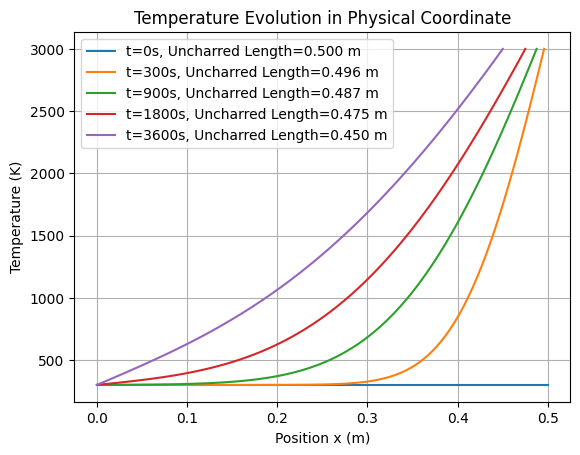

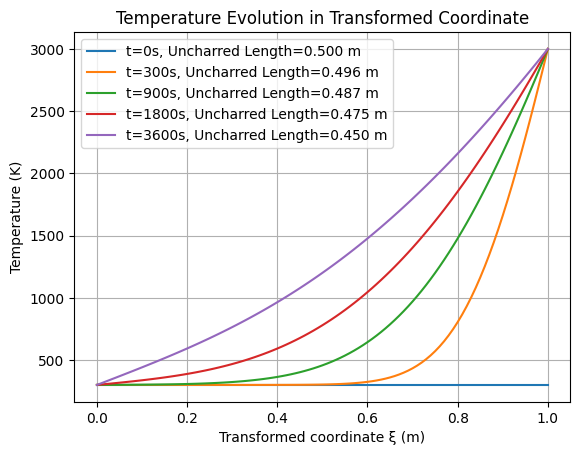

In [4]:
times = [0, 300, 900, 1800, 3600]

# Figure 1: physical coordinate
pl.figure()

for tt in times:
    idx = int(tt / dt)

    x_phys = xi * (L - s(t[idx]))
    length = L - s(t[idx])

    pl.plot(
        x_phys,
        T[idx, :],
        label=f"t={tt}s, Uncharred Length={length:.3f} m"
    )

pl.legend()
pl.grid()
pl.xlabel("Position x (m)")
pl.ylabel("Temperature (K)")
pl.title("Temperature Evolution in Physical Coordinate")
pl.show()


# Figure 2: transformed coordinate
pl.figure()

for tt in times:
    idx = int(tt / dt)

    length = L - s(t[idx])

    pl.plot(
        xi,
        T[idx, :],
        label=f"t={tt}s, Uncharred Length={length:.3f} m"
    )

pl.legend()
pl.grid()
pl.xlabel("Transformed coordinate ξ (m)")
pl.ylabel("Temperature (K)")
pl.title("Temperature Evolution in Transformed Coordinate")
pl.show()

boundary recession due to charring. Set rate to be constant here.

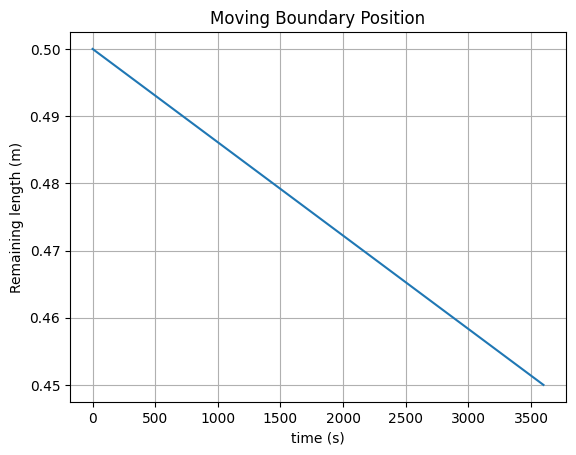

In [5]:
lengths = L - s(t)

pl.figure()

pl.plot(t, lengths)

pl.xlabel("time (s)")
pl.ylabel("Remaining length (m)")
pl.title("Moving Boundary Position")

pl.grid()

Multiplying the first-derivative term by a factor of 100 greatly increases the transformed advection velocity

$$
v(\xi,t)=\frac{\xi s'(t)}{L-s(t)}.
$$

As a result, the equation becomes more advection-dominated. The temperature profile is expected to become more skewed, with a sharper thermal boundary layer near the heated boundary. Diffusion tends to smooth the temperature distribution, while the enlarged advection term transports the profile more strongly in the transformed coordinate. Therefore, the heat penetration into the interior becomes less smooth and the temperature rise becomes more concentrated near the hot boundary.

Numerically, this stronger advection also makes central differencing less reliable and can lead to oscillations. An upwind discretisation is therefore preferred for the first-derivative term.

### Discuss About K

K(t) using explicit method in moving boundary


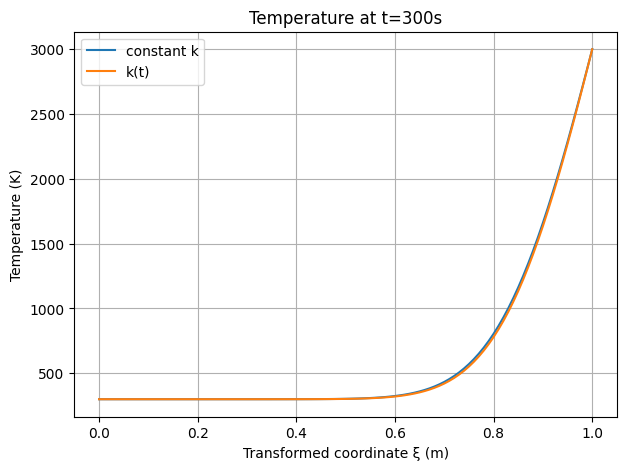

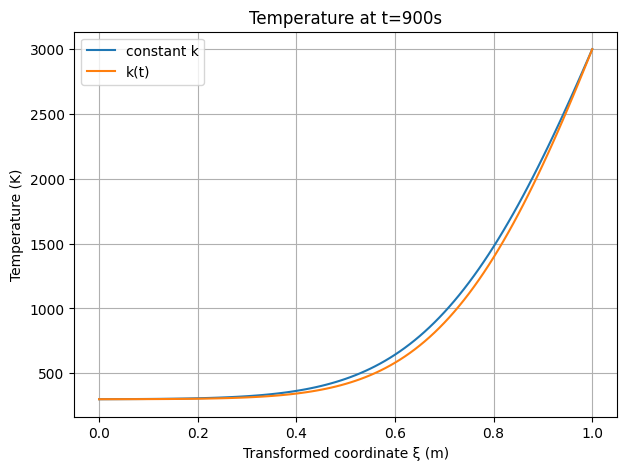

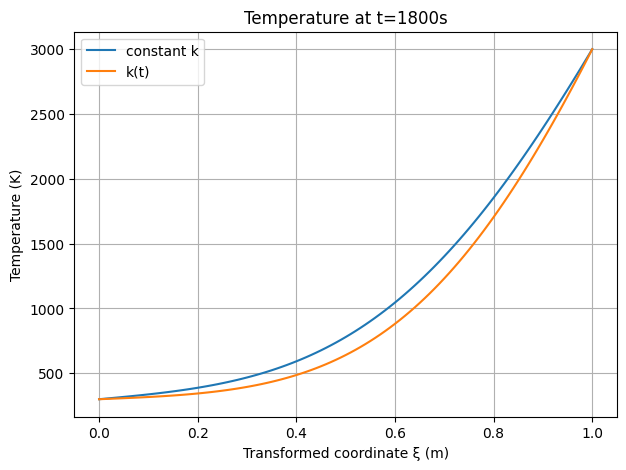

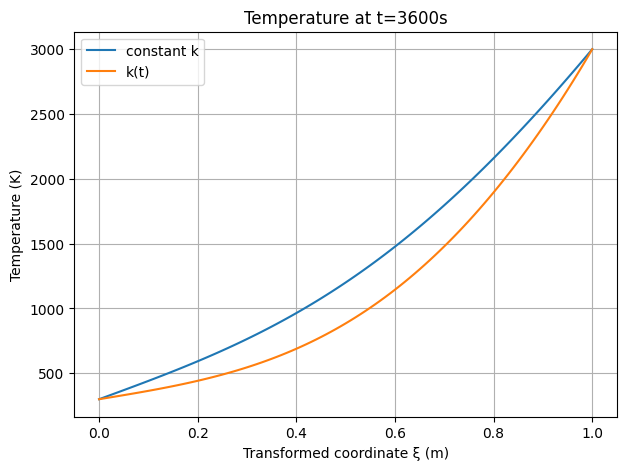

In [6]:
k0 = 1e-5

def k_const(t):
    return k0

def k_time(t):
    return k0 * np.exp(-t/3600)

def solve_temperature(kfunc):

    T = np.zeros((Nt, Nxi))
    T[0,:] = T0

    for i in range(1, Nt):

        T[i,0] = Ta
        T[i,-1] = Tb

        scale = L - s(t[i])

        acoef = kfunc(t[i]) * dt / (dxi**2 * scale**2)

        for j in range(1, Nxi-1):

            bcoef = (dt * xi[j] * ds_dt(t[i]) / (2 * dxi * scale))

            T[i,j] = (acoef * (T[i-1, j+1] + T[i-1, j-1]) + (1 - 2 * acoef) * T[i-1, j] - bcoef * (T[i-1, j+1] - T[i-1, j-1]))

    return T

T_const = solve_temperature(k_const)
T_time  = solve_temperature(k_time)


times = [300, 900, 1800, 3600]

for tt in times:

    idx = int(tt/dt)

    pl.figure(figsize=(7,5))

    pl.plot(
        xi,
        T_const[idx,:],
        label="constant k"
    )

    pl.plot(
        xi,
        T_time[idx,:],
        label="k(t)"
    )

    pl.xlabel("Transformed coordinate ξ (m)")
    pl.ylabel("Temperature (K)")
    pl.title(f"Temperature at t={tt}s")

    pl.grid(True)
    pl.legend()

    pl.show()

### The case of K(T):
$$
\frac{\partial}{\partial x}\left(K(T)\,T_x\right) = \frac{\partial T}{\partial t}
$$

heat flux obeys Fourier law：

$$
q=-K(T)\frac{\partial T}{\partial x}
$$

conservation law:

$$
T_t=-q_x
$$

Then it is:

$$
T_t=\frac{\partial}{\partial x}\left(K(T)T_x\right)
$$


To model it numerically:

→ compute heat flux
$$
q_{i+\frac12}
\approx
K_{i+\frac12}
\frac{T_{i+1}-T_i}{\Delta x}
$$
→ compute flux divergence
$$
\frac{q_{i+\frac12}-q_{i-\frac12}}{\Delta x}
$$
→ update temperature explicitly
$$
T^{n+1}=T^n+\Delta t\,T_t
$$

```text
# conductivity at cell faces
Kp = K(0.5*(T[p-1,i] + T[p-1,i+1]))
Km = K(0.5*(T[p-1,i] + T[p-1,i-1]))

# heat fluxes
flux_r = Kp*(T[p-1,i+1] - T[p-1,i])/dx
flux_l = Km*(T[p-1,i] - T[p-1,i-1])/dx

# divergence of flux
diff = (flux_r - flux_l)/dx

# explicit update
T[p,i] = T[p-1,i] + dt*diff
```

we can vary several K(T) for the solution for fixed boundary

Note: we dont have change of coordinates here so its the normal case when length 0 <= x <= 0.5

In [7]:
x_0 = 0
x_1 = 0.5
dx = 0.01
x = np.arange(x_0, x_1 + dx, dx)
Nx = len(x)

t_0 = 0
t_1 = 3600
dt = 0.01
t = np.arange(t_0, t_1 + dt, dt)
Nt = len(t)

Ta = 300 
Tb = 3000
T0 = 300

$$
K(T) = K_0 * (1 + \alpha T)
$$

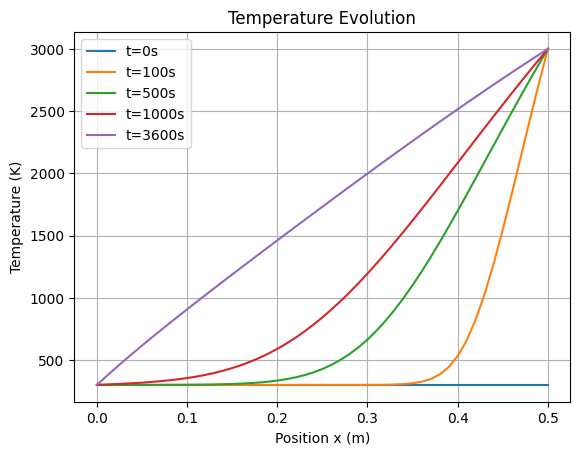

In [8]:
# set different K(T)
K0 = 1e-5
alpha = 5e-4

def K(T):
    return K0 * (1 + alpha * T)


# T[i, j] represents T_i^j
# i = time index
# j = space index
T = np.ndarray((Nt, Nx))
T[0, :] = T0

for i in range(1, Nt):

    # boundary conditions
    T[i, 0] = Ta
    T[i, Nx - 1] = Tb

    for j in range(1, Nx - 1):

        # conductivity at cell faces
        K_plus = K(0.5 * (T[i-1, j] + T[i-1, j+1]))
        K_minus = K(0.5 * (T[i-1, j] + T[i-1, j-1]))

        # heat fluxes at right and left faces
        flux_plus = K_plus * (T[i-1, j+1] - T[i-1, j]) / dx
        flux_minus = K_minus * (T[i-1, j] - T[i-1, j-1]) / dx

        # divergence of flux
        diff = (flux_plus - flux_minus) / dx

        # explicit update
        T[i, j] = T[i-1, j] + dt * diff


times = [0, 100, 500, 1000, 3600]

for tt in times:
    i = int(tt / dt)
    pl.plot(x, T[i, :], label=f"t={tt}s")

pl.xlabel("Position x (m)")
pl.ylabel("Temperature (K)")
pl.title("Temperature Evolution")
pl.legend()
pl.grid(True)
pl.show()

$$
K(T) = K_0 / (1 + \alpha T)
$$

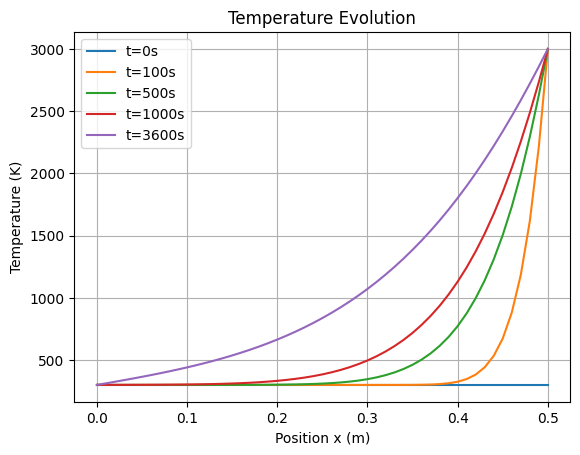

In [9]:
# set different K(T)
K0 = 1e-5
alpha = 5e-4

def K(T):
    return K0 / (1 + alpha * T)

T = np.ndarray((Nt, Nx))
T[0, :] = T0

for i in range(1, Nt):

    T[i, 0] = Ta
    T[i, Nx - 1] = Tb

    for j in range(1, Nx - 1):

        K_plus = K(0.5 * (T[i-1, j] + T[i-1, j+1]))
        K_minus = K(0.5 * (T[i-1, j] + T[i-1, j-1]))

        flux_plus = K_plus * (T[i-1, j+1] - T[i-1, j]) / dx
        flux_minus = K_minus * (T[i-1, j] - T[i-1, j-1]) / dx

        diff = (flux_plus - flux_minus) / dx

        T[i, j] = T[i-1, j] + dt * diff


times = [0, 100, 500, 1000, 3600]

for tt in times:
    i = int(tt / dt)
    pl.plot(x, T[i, :], label=f"t={tt}s")

pl.xlabel("Position x (m)")
pl.ylabel("Temperature (K)")
pl.title("Temperature Evolution")
pl.legend()
pl.grid(True)
pl.show()

$$
K(T) = K_0 e^{\alpha T}
$$

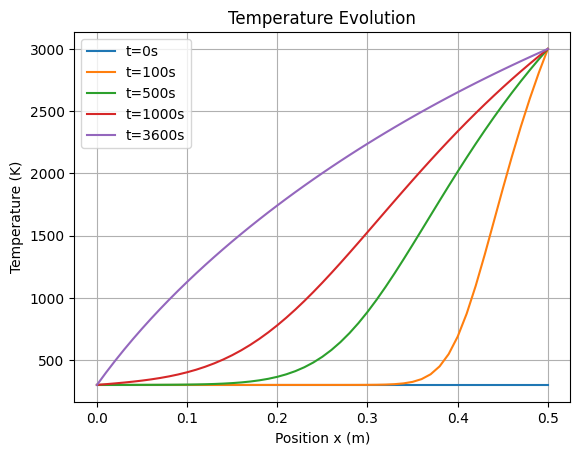

In [10]:
import math

K0 = 1e-5
alpha = 5e-4

def K(T):
    return K0 * math.exp(alpha * T)

T = np.ndarray((Nt, Nx))
T[0, :] = T0

for i in range(1, Nt):

    T[i, 0] = Ta
    T[i, Nx - 1] = Tb

    for j in range(1, Nx - 1):

        K_plus = K(0.5 * (T[i-1, j] + T[i-1, j+1]))
        K_minus = K(0.5 * (T[i-1, j] + T[i-1, j-1]))

        flux_plus = K_plus * (T[i-1, j+1] - T[i-1, j]) / dx
        flux_minus = K_minus * (T[i-1, j] - T[i-1, j-1]) / dx

        diff = (flux_plus - flux_minus) / dx

        T[i, j] = T[i-1, j] + dt * diff


times = [0, 100, 500, 1000, 3600]

for tt in times:
    i = int(tt / dt)
    pl.plot(x, T[i, :], label=f"t={tt}s")

pl.xlabel("Position x (m)")
pl.ylabel("Temperature (K)")
pl.title("Temperature Evolution")
pl.legend()
pl.grid(True)
pl.show()

### Now switch to Varying K(T) with Advection term
$$
\frac{\partial T}{\partial t}
=
\frac{1}{(L-s(t))^2}\frac{\partial}{\partial \xi}\left(K(T)\,T_\xi\right)
-
\frac{\xi\,s'(t)}{L-s(t)}\frac{\partial T}{\partial \xi}
$$
the first term represents nonlinear heat diffusion with temperature-dependent conductivity, while the second term arises from the coordinate transformation associated with boundary recession.

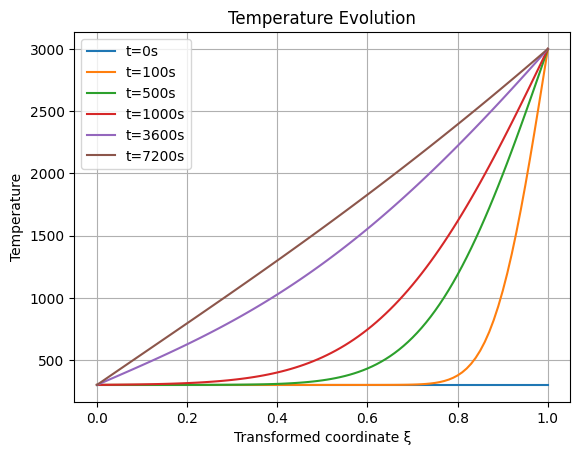

In [11]:
xi_0 = 0
xi_1 = 1
dxi = 0.01
xi = np.arange(xi_0, xi_1 + dxi, dxi)
Nxi = len(xi)

t_0 = 0
t_1 = 7200
dt = 0.01
t = np.arange(t_0, t_1 + dt, dt)
Nt = len(t)

Ta = 300 
Tb = 3000
T0 = 300

# set different K(T)
K0 = 1e-5
alpha = 5e-5
def K(T):
    return K0 * (1 + alpha * T)

T = np.ndarray((Nt, Nxi))
T[0,:] = T0

for p in range(1, Nt):
    T[p, 0] = Ta
    T[p, Nxi - 1] = Tb

    delta = L - s(t[p])

    for i in range(1, Nxi-1):

        Kp = K(0.5*(T[p-1,i] + T[p-1,i+1]))
        Km = K(0.5*(T[p-1,i] + T[p-1,i-1]))

        flux_r = Kp*(T[p-1,i+1] - T[p-1,i])/dxi
        flux_l = Km*(T[p-1,i] - T[p-1,i-1])/dxi

        diff = (flux_r - flux_l)/(dxi*delta**2)

        # transformed advection velocity
        v = xi[i]*ds_dt(t[p])/delta

        # upwind advection
        adv = v*(T[p-1,i] - T[p-1,i-1])/dxi

        # explicit update
        T[p,i] = T[p-1,i] + dt*(diff - adv)

times = [0,100,500,1000,3600,7200]

for tt in times:
    idx = int(tt/dt)
    pl.plot(xi,T[idx,:],label=f"t={tt}s")

pl.xlabel("Transformed coordinate ξ")
pl.ylabel("Temperature")
pl.title("Temperature Evolution")
pl.legend()
pl.grid(True)
pl.show()


### Effect of increasing alpha
When alpha is increased, the thermal conductivity becomes much more sensitive to temperature. Since the temperature near the right boundary is high, \(K(T)\) becomes significantly larger in that region. As a result, heat is transferred more efficiently from the high-temperature boundary into the material.

This explains why the temperature curves become more nonlinear. Instead of approaching a straight-line profile as in the constant-conductivity case, the temperature rises rapidly near the colder side and then gradually flattens toward the hotter boundary. This behaviour is caused by stronger heat conduction in the high-temperature region.

At later times, such as \(t=3600\,s\) and \(t=7200\,s\), the curves become very close to each other, which suggests that the solution is approaching a steady-state temperature distribution. However, because \(K\) depends on \(T\), the steady-state profile is not linear.

At steady state,

$$
\frac{\partial T}{\partial t}=0.
$$

Therefore, the governing equation becomes

$$
\frac{\partial}{\partial \xi}
\left(
K(T)\frac{\partial T}{\partial \xi}
\right)=0.
$$

Using

$$
K(T)=K_0(1+\alpha T),
$$

we have

$$
\frac{\partial}{\partial \xi}
\left[
K_0(1+\alpha T)\frac{\partial T}{\partial \xi}
\right]=0.
$$

After integration,

$$
K_0(1+\alpha T)\frac{\partial T}{\partial \xi}=C.
$$

Since \(K_0\) is constant, this gives

$$
(1+\alpha T)\frac{\partial T}{\partial \xi}=C_1.
$$

Integrating again gives

$$
T+\frac{\alpha}{2}T^2=C_1\xi+C_2.
$$

Therefore, \(T\) is nonlinear with respect to the transformed coordinate, which agrees with the curved temperature profiles shown in the numerical result.

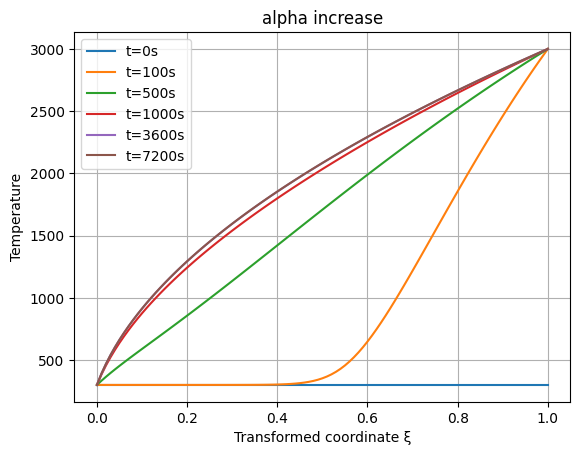

In [12]:
xi_0 = 0
xi_1 = 1
dxi = 0.01
xi = np.arange(xi_0, xi_1 + dxi, dxi)
Nxi = len(xi)

t_0 = 0
t_1 = 7200
dt = 0.01
t = np.arange(t_0, t_1 + dt, dt)
Nt = len(t)

Ta = 300 
Tb = 3000
T0 = 300

# set different K(T)
K0 = 1e-5
alpha = 5e-3
def K(T):
    return K0 * (1 + alpha * T)

T = np.ndarray((Nt, Nxi))
T[0,:] = T0

for p in range(1, Nt):
    T[p, 0] = Ta
    T[p, Nxi - 1] = Tb

    delta = L - s(t[p])

    for i in range(1, Nxi-1):

        Kp = K(0.5*(T[p-1,i] + T[p-1,i+1]))
        Km = K(0.5*(T[p-1,i] + T[p-1,i-1]))

        flux_r = Kp*(T[p-1,i+1] - T[p-1,i])/dxi
        flux_l = Km*(T[p-1,i] - T[p-1,i-1])/dxi

        diff = (flux_r - flux_l)/(dxi*delta**2)

        # transformed advection velocity
        v = xi[i]*ds_dt(t[p])/delta

        # upwind advection
        adv = v*(T[p-1,i] - T[p-1,i-1])/dxi

        # explicit update
        T[p,i] = T[p-1,i] + dt*(diff - adv)

times = [0,100,500,1000,3600,7200]

for tt in times:
    idx = int(tt/dt)
    pl.plot(xi,T[idx,:],label=f"t={tt}s")

pl.xlabel("Transformed coordinate ξ")
pl.ylabel("Temperature")
pl.title("alpha increase")
pl.legend()
pl.grid(True)
pl.show()


Explicit Unstable Case when 
$$\Delta t  = 1$$
the method fully diverges according to:
$$
\frac{\max(K(T)) \,\Delta t}{\Delta x^2} \ge \frac{1}{2}
$$

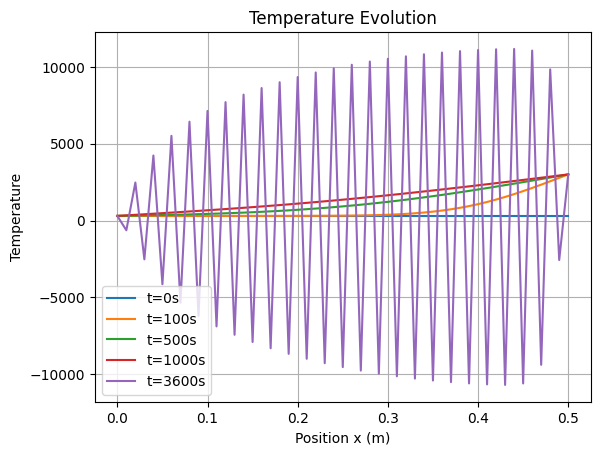

In [13]:
import numpy as np
import matplotlib.pyplot as pl

xi_0 = 0
xi_1 = 0.5
dxi = 0.01
xi = np.arange(xi_0, xi_1 + dxi, dxi)
Nxi = len(xi)

t_0 = 0
t_1 = 3600
dt = 1
t = np.arange(t_0, t_1 + dt, dt)
Nt = len(t)

Ta = 300 
Tb = 3000
T0 = 300

# set different K(T)
K0 = 1e-5
alpha = 5e-5
def K(T):
    return K0 * (1 + alpha * T)

T = np.ndarray((Nt, Nxi))
T[0,:] = T0

for p in range(1, Nt):
    T[p, 0] = Ta
    T[p, Nxi - 1] = Tb

    delta = L - s(t[p])

    for i in range(1, Nxi-1):

        # conductivity at faces
        Kp = K(0.5*(T[p-1,i] + T[p-1,i+1]))
        Km = K(0.5*(T[p-1,i] + T[p-1,i-1]))

        # nonlinear fluxes
        flux_r = Kp*(T[p-1,i+1] - T[p-1,i])/dxi
        flux_l = Km*(T[p-1,i] - T[p-1,i-1])/dxi

        diff = (flux_r - flux_l)/(dxi*delta**2)

        # transformed advection velocity
        v = xi[i]*ds_dt(t[p])/delta

        # upwind advection
        adv = v*(T[p-1,i] - T[p-1,i-1])/dxi

        # explicit update
        T[p,i] = T[p-1,i] + dt*(diff - adv)

times = [0,100,500,1000,3600]

for tt in times:
    idx = int(tt/dt)
    pl.plot(xi,T[idx,:],label=f"t={tt}s")

pl.xlabel("Position x (m)")
pl.ylabel("Temperature")
pl.title("Temperature Evolution")
pl.legend()
pl.grid(True)
pl.show()


Therefore we use Implicit method for the ultimate equation to ensure stability

### Implicit Method with Lagged Conductivity

We solve the transformed nonlinear heat equation

$$
\frac{\partial T}{\partial t}
=
\frac{1}{\delta(t)^2}
\frac{\partial}{\partial \xi}
\left(
K(T)\frac{\partial T}{\partial \xi}
\right)
-
v(\xi,t)\frac{\partial T}{\partial \xi},
$$

where

$$
\delta(t)=L-s(t),
\qquad
v_j^{i+1}
=
\frac{\xi_j s'(t_{i+1})}{\delta^{i+1}}.
$$

Since \(K\) depends on \(T\), the diffusion coefficient is nonlinear. To avoid solving a fully nonlinear system, a lagged-coefficient approach is used. The conductivity at cell faces is evaluated using the previous time level:

$$
K_{j+\frac12}^{i,\mathrm{lag}}
=
K\left(
\frac{T_j^i+T_{j+1}^i}{2}
\right),
$$

and

$$
K_{j-\frac12}^{i,\mathrm{lag}}
=
K\left(
\frac{T_j^i+T_{j-1}^i}{2}
\right).
$$

The temperature itself is still solved implicitly at the new time level. The discretised equation is

$$
\frac{T_j^{i+1}-T_j^i}{\Delta t}
=
\frac{1}{(\delta^{i+1})^2}
\frac{
K_{j+\frac12}^{i,\mathrm{lag}}
\left(
\frac{T_{j+1}^{i+1}-T_j^{i+1}}{\Delta \xi}
\right)
-
K_{j-\frac12}^{i,\mathrm{lag}}
\left(
\frac{T_j^{i+1}-T_{j-1}^{i+1}}{\Delta \xi}
\right)
}{\Delta \xi}
-
v_j^{i+1}
\frac{T_j^{i+1}-T_{j-1}^{i+1}}{\Delta \xi}.
$$

For \(v_j^{i+1}\ge 0\), backward upwinding is used for the advection term. Define

$$
C_{j+\frac12}
=
\frac{\Delta t}{(\Delta \xi)^2(\delta^{i+1})^2}
K_{j+\frac12}^{i,\mathrm{lag}},
$$

$$
C_{j-\frac12}
=
\frac{\Delta t}{(\Delta \xi)^2(\delta^{i+1})^2}
K_{j-\frac12}^{i,\mathrm{lag}},
$$

and

$$
B_j
=
\frac{\Delta t}{\Delta \xi}v_j^{i+1}.
$$

Then the interior equation becomes

$$
T_j^i
=
(-C_{j-\frac12}-B_j)T_{j-1}^{i+1}
+
(1+C_{j-\frac12}+C_{j+\frac12}+B_j)T_j^{i+1}
-
C_{j+\frac12}T_{j+1}^{i+1}.
$$

Therefore, the implicit method gives a tridiagonal linear system

$$
A(T^i)T^{i+1}=b.
$$

The key idea is that the conductivity is lagged from the known temperature $T^i$, while the new temperature $T^{i+1}$ is solved implicitly. This avoids a fully nonlinear solve while retaining better stability than the explicit method.
```


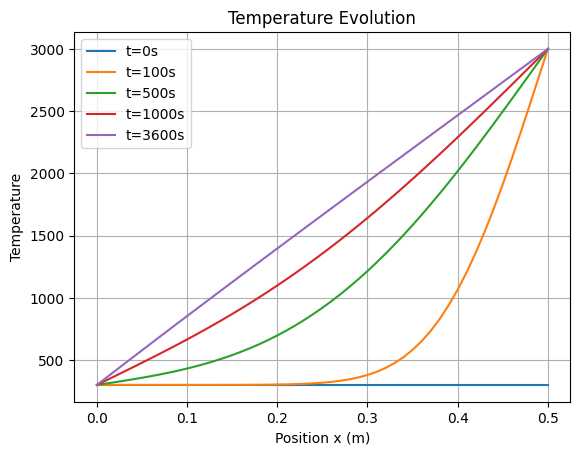

In [ ]:
import numpy as np

T = np.zeros((Nt, Nxi))
T[0,:] = T0
 
tol = 1e-6
max_iter = 50

for p in range(1, Nt):

    # boundary
    Tn = T[p-1,:].copy()

    # initial guess
    T_guess = Tn.copy()

    for m in range(max_iter):

        A = np.zeros((Nxi, Nxi))
        b = Tn.copy()

        delta = L - s(t[p])

        # boundary conditions
        A[0,0] = 1
        b[0] = Ta

        A[-1,-1] = 1
        b[-1] = Tb

        for i in range(1, Nxi-1):

            # --- conductivity from previous iteration ---
            Kp = K(0.5*(T_guess[i] + T_guess[i+1]))
            Km = K(0.5*(T_guess[i] + T_guess[i-1]))

            # diffusion coefficients
            Cp = dt * Kp / (dxi**2 * delta**2)
            Cm = dt * Km / (dxi**2 * delta**2)

            # advection velocity (still explicit or lagged)
            v = xi[i] * ds_dt(t[p]) / delta

            A[i,i-1] = -Cm - dt * max(v,0)/dxi
            A[i,i]   = 1 + Cp + Cm + dt * abs(v)/dxi
            A[i,i+1] = -Cp + dt * min(v,0)/dxi

        # solve linear system
        T_new = np.linalg.solve(A, b)

        # check convergence
        if np.linalg.norm(T_new - T_guess) < tol:
            break

        T_guess = T_new

    T[p,:] = T_new

times = [0,100,500,1000,3600]

for tt in times:
    idx = int(tt/dt)
    pl.plot(xi,T[idx,:],label=f"t={tt}s")

pl.xlabel("Position x (m)")
pl.ylabel("Temperature")
pl.title("Temperature Evolution")
pl.legend()
pl.grid(True)
pl.show()


### Discussion：Compare to analytic solution

$$
\frac{\partial T}{\partial t}
=
\frac{\partial}{\partial x}
\left(
K(T)\frac{\partial T}{\partial x}
\right),
$$

when

$$
K(T)=aT,
$$

one analytical solution is

$$
T(x,t)
=
a^{-1}t^{-\frac{1}{3}}
\left(
c-\frac{1}{6}x^2t^{-\frac{2}{3}}
\right).
$$

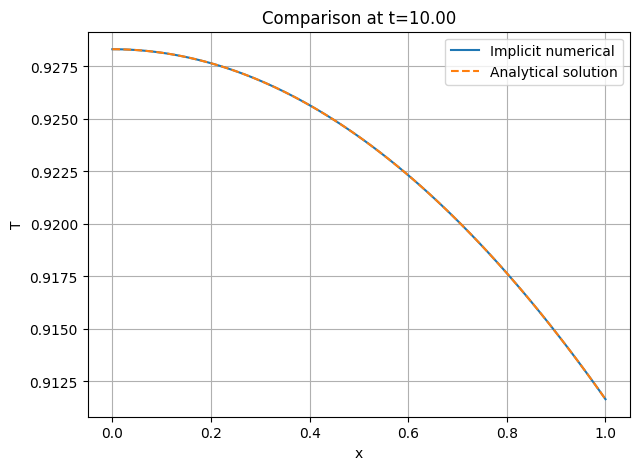

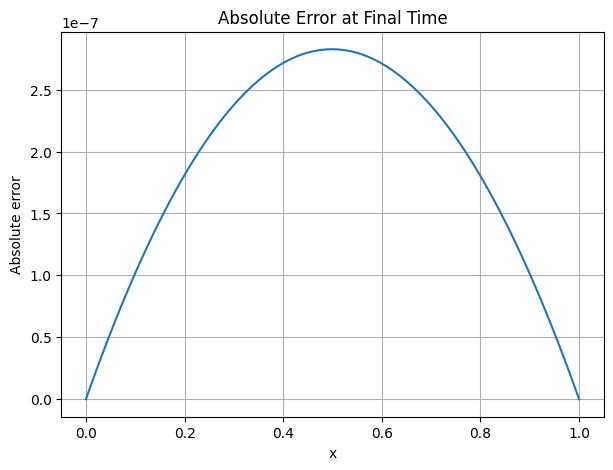

Max error at final time: 2.826000158329123e-07
Picard iterations used in last step: 2


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# PDE:
# T_t = d/dx( K(T) T_x )
# K(T) = a*T
# --------------------------------------------------

# Parameters
a = 1.0
c = 2.0

# Spatial domain
x0 = 0.0
x1 = 1.0
dx = 0.01
x = np.arange(x0, x1 + dx, dx)
Nx = len(x)

# Time domain
# Start from t0 > 0 because the analytical solution is singular at t=0
t0 = 1.0
t1 = 10.0
dt = 0.001
t = np.arange(t0, t1 + dt, dt)
Nt = len(t)

# Picard settings
tol = 1e-8
max_iter = 50


def T_exact(x, t):
    return (1/a) * t**(-1/3) * (c - (1/6)*x**2*t**(-2/3))


def K(T):
    return a*T


# Numerical solution
T = np.zeros((Nt, Nx))

# Initial condition from analytical solution
T[0, :] = T_exact(x, t[0])

# Time stepping
for n in range(1, Nt):

    Tn = T[n-1, :].copy()

    # Initial guess for Picard iteration
    T_guess = Tn.copy()

    for m in range(max_iter):

        A = np.zeros((Nx, Nx))
        b = Tn.copy()

        # Dirichlet boundary conditions from exact solution
        A[0, 0] = 1.0
        b[0] = T_exact(x[0], t[n])

        A[-1, -1] = 1.0
        b[-1] = T_exact(x[-1], t[n])

        # Interior points
        for i in range(1, Nx-1):

            # Conductivity at cell faces, evaluated using previous Picard guess
            Kp = K(0.5*(T_guess[i] + T_guess[i+1]))
            Km = K(0.5*(T_guess[i] + T_guess[i-1]))

            Cp = dt * Kp / dx**2
            Cm = dt * Km / dx**2

            # Implicit flux-form matrix
            A[i, i-1] = -Cm
            A[i, i]   = 1 + Cp + Cm
            A[i, i+1] = -Cp

        # Solve linear system
        T_new = np.linalg.solve(A, b)

        # Picard convergence check
        if np.linalg.norm(T_new - T_guess, ord=np.inf) < tol:
            break

        T_guess = T_new

    T[n, :] = T_new


# Exact solution on the same grid
T_ex = np.zeros_like(T)
for n in range(Nt):
    T_ex[n, :] = T_exact(x, t[n])

# --------------------------------------------------
# Plot comparison at final time
# --------------------------------------------------

plt.figure(figsize=(7,5))
plt.plot(x, T[-1, :], label="Implicit numerical")
plt.plot(x, T_ex[-1, :], "--", label="Analytical solution")
plt.xlabel("x")
plt.ylabel("T")
plt.title(f"Comparison at t={t[-1]:.2f}")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Plot error
# --------------------------------------------------

error = np.abs(T[-1, :] - T_ex[-1, :])

plt.figure(figsize=(7,5))
plt.plot(x, error)
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.title("Absolute Error at Final Time")
plt.grid(True)
plt.show()

print("Max error at final time:", np.max(error))
print("Picard iterations used in last step:", m+1)

For

$$
K(T)=k_0 e^{\beta T},
$$

an implicit analytical form is

$$
-\frac{v}{k_0}(x-vt)+c
=
\sum_{n=1}^{\infty}
\frac{\beta^n T^n}{n!n}
+
\frac{1}{\beta}\log(T).
$$

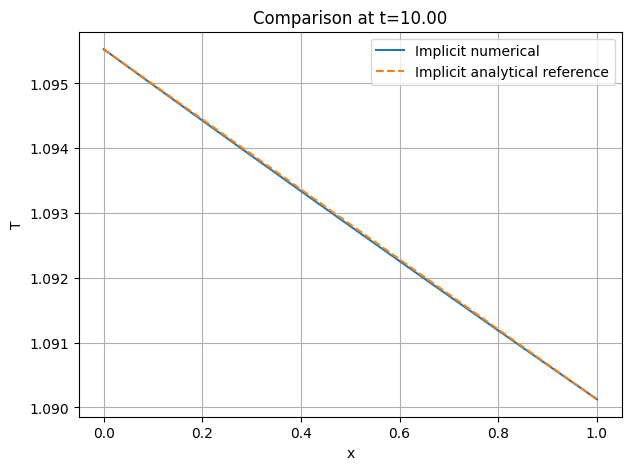

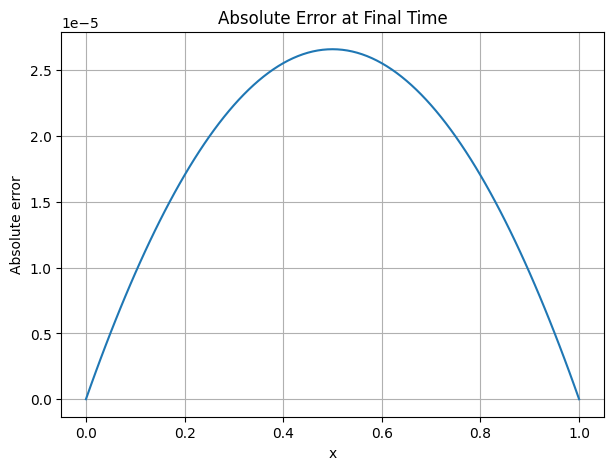

Max error at final time: 2.6603305418149148e-05
Picard iterations used in last step: 2


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# PDE:
# T_t = d/dx( K(T) T_x )
# K(T) = k0 * exp(beta*T)
# --------------------------------------------------

# Parameters
k0 = 1.0
beta = 0.1
v = 0.05
c_const = 1.0

# Spatial domain
x0 = 0.0
x1 = 1.0
dx = 0.01
x = np.arange(x0, x1 + dx, dx)
Nx = len(x)

# Time domain
t0 = 0.0
t1 = 10.0
dt = 0.01
t = np.arange(t0, t1 + dt, dt)
Nt = len(t)

# Picard settings
tol = 1e-8
max_iter = 50


# --------------------------------------------------
# Conductivity
# --------------------------------------------------

def K(T):
    return k0 * np.exp(beta * T)


# --------------------------------------------------
# H(T) from the implicit analytical formula
# --------------------------------------------------

def H(T, n_terms=80):
    """
    H(T) = sum_{n=1}^infty beta^n T^n/(n! n)
           + (1/beta) log(T)

    This follows the implicit analytical form given.
    """
    if T <= 0:
        return -np.inf

    series_sum = 0.0
    term = 1.0

    for n in range(1, n_terms + 1):
        term *= beta * T / n      # term = (beta*T)^n / n!
        series_sum += term / n

    return series_sum + (1.0 / beta) * np.log(T)


def RHS_implicit(x, t):
    return -v / k0 * (x - v * t) + c_const


def solve_T_exact_single(xval, tval):
    """
    Solve H(T) = RHS(x,t) by bisection.
    """
    target = RHS_implicit(xval, tval)

    lo = 1e-10
    hi = 10.0

    # Increase upper bound until root is bracketed
    while H(hi) < target:
        hi *= 2.0

    for _ in range(100):
        mid = 0.5 * (lo + hi)

        if H(mid) < target:
            lo = mid
        else:
            hi = mid

    return 0.5 * (lo + hi)


def T_exact(x_array, tval):
    return np.array([solve_T_exact_single(xx, tval) for xx in x_array])


# --------------------------------------------------
# Numerical implicit Picard solver
# --------------------------------------------------

T = np.zeros((Nt, Nx))

# Initial condition from analytical solution
T[0, :] = T_exact(x, t[0])

for n in range(1, Nt):

    Tn = T[n-1, :].copy()
    T_guess = Tn.copy()

    for m in range(max_iter):

        A = np.zeros((Nx, Nx))
        b = Tn.copy()

        # Dirichlet boundary conditions from exact solution
        A[0, 0] = 1.0
        b[0] = solve_T_exact_single(x[0], t[n])

        A[-1, -1] = 1.0
        b[-1] = solve_T_exact_single(x[-1], t[n])

        for i in range(1, Nx - 1):

            # Conductivity at faces using previous Picard guess
            Kp = K(0.5 * (T_guess[i] + T_guess[i+1]))
            Km = K(0.5 * (T_guess[i] + T_guess[i-1]))

            Cp = dt * Kp / dx**2
            Cm = dt * Km / dx**2

            # Implicit flux-form matrix
            A[i, i-1] = -Cm
            A[i, i]   = 1.0 + Cp + Cm
            A[i, i+1] = -Cp

        T_new = np.linalg.solve(A, b)

        if np.linalg.norm(T_new - T_guess, ord=np.inf) < tol:
            break

        T_guess = T_new

    T[n, :] = T_new


# --------------------------------------------------
# Exact solution on full grid
# --------------------------------------------------

T_ex = np.zeros_like(T)

for n in range(Nt):
    T_ex[n, :] = T_exact(x, t[n])


# --------------------------------------------------
# Plot comparison at final time
# --------------------------------------------------

plt.figure(figsize=(7,5))
plt.plot(x, T[-1, :], label="Implicit numerical")
plt.plot(x, T_ex[-1, :], "--", label="Implicit analytical reference")
plt.xlabel("x")
plt.ylabel("T")
plt.title(f"Comparison at t={t[-1]:.2f}")
plt.grid(True)
plt.legend()
plt.show()


# --------------------------------------------------
# Plot absolute error
# --------------------------------------------------

error = np.abs(T[-1, :] - T_ex[-1, :])

plt.figure(figsize=(7,5))
plt.plot(x, error)
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.title("Absolute Error at Final Time")
plt.grid(True)
plt.show()

print("Max error at final time:", np.max(error))
print("Picard iterations used in last step:", m + 1)

### Extra $\frac{\partial \rho}{\partial t}$ Term, Gamma Term : Full Model

basically it just add a constant to the adjusted advection diffusion equation as:

$$
\frac{\partial T}{\partial t}
=
\frac{1}{(L-s(t))^2}\frac{\partial}{\partial \xi}\left(K(T)\,T_\xi\right)
-
\frac{\xi\,s'(t) - \Gamma}{L-s(t)}\frac{\partial T}{\partial \xi}
$$

Modefying the code is eazy as well so we'll skip it.

using so called unimoleecular law we can transform it into a function so called "Arrhenius" term.
Then its ok to simulate it by central differences.

The rate of density change is assumed to follow an Arrhenius-type expression:

$$
\frac{\partial \rho}{\partial t}
=
-A\rho \exp\left(-\frac{E}{RT}\right),
$$

where

$
A
$
is the pre-exponential factor,

$
E
$
is the activation energy,

$
R
$
is the universal gas constant, and

$
T
$
is the local temperature.

The reaction rate can be written as

$$
\lambda(T)
=
A\exp\left(-\frac{E}{RT}\right).
$$

Therefore,

$$
\frac{\partial \rho}{\partial t}
=
-\lambda(T)\rho.
$$

If \(T\) is locally fixed during one timestep, the density can be updated by separation of variables

$$
\rho^{n+1}
=
\rho^n
\exp\left(-\lambda(T^n)\Delta t\right).
$$

Hence,

$$
\left(\frac{\partial \rho}{\partial t}\right)^n
\approx
\frac{\rho^{n+1}-\rho^n}{\Delta t}.
$$

$$
\frac{\partial T}{\partial t}
=
\frac{1}{(L-s(t))^2}\frac{\partial}{\partial \xi}\left(K(T)\,T_\xi\right)
-
\frac{\xi\,s'(t) - \Gamma}{L-s(t)}\frac{\partial T}{\partial \xi}
+
C_\rho \frac{\partial \rho}{\partial t}
$$


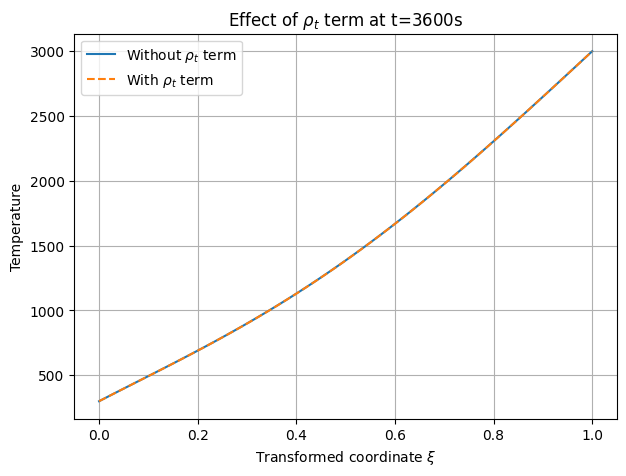

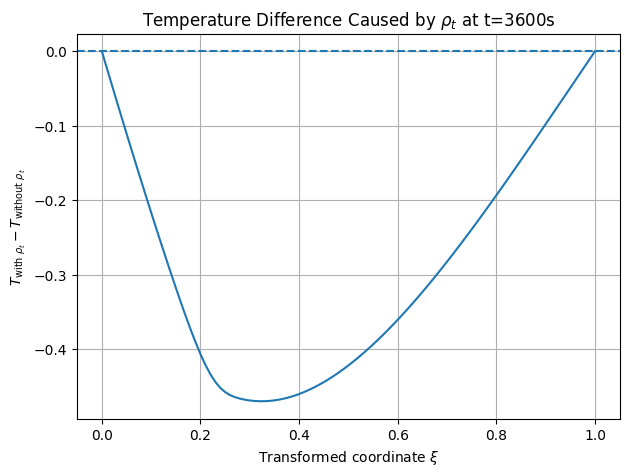

Max absolute difference: 0.4700024552976174


In [2]:
import numpy as np
import matplotlib.pyplot as pl

xi_0 = 0
xi_1 = 1
dxi = 0.01
xi = np.arange(xi_0, xi_1 + dxi, dxi)
Nxi = len(xi)

t_0 = 0
t_1 = 7200
dt = 1
t = np.arange(t_0, t_1 + dt, dt)
Nt = len(t)

L = 0.5
r = 0.05 / 3600
d = 0
def s(t): 
    return r * t + d
def ds_dt(t):
    return r

K0 = 1e-5
alpha = 5e-5
def K(T):
    return K0 * (1 + alpha * T)

Gamma = 1e-5

Ta = 300 
Tb = 3000
T0 = 300

rho0 = 1.0
A_arr = 1e3
E = 8e4
Rgas = 8.314

C_rho = 1.0

rho = np.zeros((Nt, Nxi))
rho[0, :] = rho0

T = np.zeros((Nt, Nxi))
T[0, :] = T0
T[0, 0] = Ta
T[0, -1] = Tb

tol = 1e-6
max_iter = 50

def solve_temperature(use_rho_term=True):

    rho = np.zeros((Nt, Nxi))
    rho[0, :] = rho0

    T = np.zeros((Nt, Nxi))
    T[0, :] = T0
    T[0, 0] = Ta
    T[0, -1] = Tb

    for p in range(1, Nt):

        Tn = T[p-1, :].copy()
        rhon = rho[p-1, :].copy()

        # --------------------------------------------------
        # 1. Update rho using lagged Arrhenius law
        # --------------------------------------------------

        rate = A_arr * np.exp(-E / (Rgas * np.maximum(Tn, 1e-12)))

        rho_new = rhon * np.exp(-rate * dt)

        rho_t = (rho_new - rhon) / dt

        rho[p, :] = rho_new

        # --------------------------------------------------
        # 2. Picard initial guess for T
        # --------------------------------------------------

        T_guess = Tn.copy()

        for m in range(max_iter):

            A = np.zeros((Nxi, Nxi))

            b = Tn.copy()

            # add rho_t source only if requested
            if use_rho_term:
                b[1:-1] += dt * C_rho * rho_t[1:-1]

            delta = L - s(t[p])

            # boundary conditions
            A[0, 0] = 1
            b[0] = Ta

            A[-1, -1] = 1
            b[-1] = Tb

            for i in range(1, Nxi-1):

                # conductivity from previous Picard iteration
                Kp = K(0.5 * (T_guess[i] + T_guess[i+1]))
                Km = K(0.5 * (T_guess[i] + T_guess[i-1]))

                # diffusion coefficients
                Cp = dt * Kp / (dxi**2 * delta**2)
                Cm = dt * Km / (dxi**2 * delta**2)

                # moving-boundary advection velocity
                v = (xi[i] * ds_dt(t[p]) - Gamma) / delta

                A[i, i-1] = -Cm - dt * max(v, 0) / dxi
                A[i, i]   = 1 + Cp + Cm + dt * abs(v) / dxi
                A[i, i+1] = -Cp + dt * min(v, 0) / dxi

            # solve linear system
            T_new = np.linalg.solve(A, b)

            # convergence check
            if np.linalg.norm(T_new - T_guess) < tol:
                break

            T_guess = T_new

        T[p, :] = T_new

    return T, rho

T_with_rho, rho_with = solve_temperature(use_rho_term=True)
T_without_rho, rho_without = solve_temperature(use_rho_term=False)

compare_time = 3600
idx = int(compare_time / dt)

pl.figure(figsize=(7,5))

pl.plot(
    xi,
    T_without_rho[idx, :],
    label=r"Without $\rho_t$ term"
)

pl.plot(
    xi,
    T_with_rho[idx, :],
    "--",
    label=r"With $\rho_t$ term"
)

pl.xlabel(r"Transformed coordinate $\xi$")
pl.ylabel("Temperature")
pl.title(rf"Effect of $\rho_t$ term at t={compare_time}s")
pl.legend()
pl.grid(True)
pl.show()

difference = T_with_rho[idx, :] - T_without_rho[idx, :]

pl.figure(figsize=(7,5))

pl.plot(xi, difference)

pl.axhline(0, linestyle="--")

pl.xlabel(r"Transformed coordinate $\xi$")
pl.ylabel(r"$T_{\mathrm{with}\ \rho_t} - T_{\mathrm{without}\ \rho_t}$")
pl.title(rf"Temperature Difference Caused by $\rho_t$ at t={compare_time}s")
pl.grid(True)
pl.show()

print("Max absolute difference:", np.max(np.abs(difference)))

### Neumann Boundary Condition
$$
\frac{\partial T}{\partial x}=0
$$

Using Central Differences:
$$
\frac{T_1^n-T_{-1}^n}{2\Delta x}=q_0
$$

ghost point：

$$
T_{-1}^n=T_1^n-2\Delta x\,q_0
$$

If q_0 = 0：

$$
T_{-1}^n=T_1^n
$$

basically changing
$$
T[p,0] = T_a
$$
$$
T[p,-1] = T_b
$$
From Dirchelt to Neumann Condition

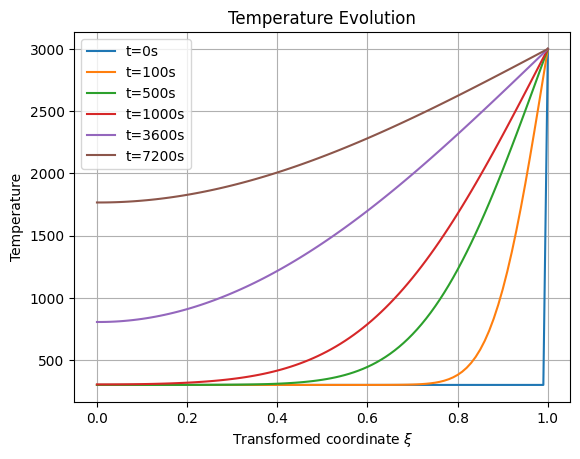

In [19]:
import numpy as np

xi_0 = 0
xi_1 = 1
dxi = 0.01
xi = np.arange(xi_0, xi_1 + dxi, dxi)
Nxi = len(xi)

t_0 = 0
t_1 = 7200
dt = 1
t = np.arange(t_0, t_1 + dt, dt)
Nt = len(t)

L = 0.5
r = 0.05 / 3600
d = 0
def s(t): 
    return r * t + d
def ds_dt(t):
    return r

K0 = 1e-5
alpha = 5e-5
def K(T):
    return K0 * (1 + alpha * T)

Gamma = 1e-5

Ta = 300 
Tb = 3000
T0 = 300

# density / Arrhenius parameters
rho0 = 1.0
A_arr = 1e3
E = 8e4
Rgas = 8.314

# coupling coefficient
C_rho = 1.0

rho = np.zeros((Nt, Nxi))
rho[0, :] = rho0

T = np.zeros((Nt, Nxi))

T[0, :] = T0
T[0, -1] = Tb

# left Neumann, q0 = 0
T[0, 0] = T[0, 1]

tol = 1e-6
max_iter = 50

for p in range(1, Nt):

    Tn = T[p-1, :].copy()
    rhon = rho[p-1, :].copy()

    # --------------------------------------------------
    # 1. Update rho using Arrhenius law
    # --------------------------------------------------

    rate = A_arr * np.exp(-E / (Rgas * np.maximum(Tn, 1e-12)))

    rho_new = rhon * np.exp(-rate * dt)

    rho_t = (rho_new - rhon) / dt

    rho[p, :] = rho_new

    # --------------------------------------------------
    # 2. Picard initial guess for T
    # --------------------------------------------------

    T_guess = Tn.copy()

    for m in range(max_iter):

        A = np.zeros((Nxi, Nxi))

        # RHS now includes rho_t source term
        b = Tn.copy()
        b[1:-1] += dt * C_rho * rho_t[1:-1]

        delta = L - s(t[p])

        # boundary conditions

        # left Neumann: T_xi(0,t) = q0
        q0 = 0.0

        A[0, 0] = 1
        A[0, 1] = -1
        b[0] = -q0 * dxi

        # right Dirichlet: T(1,t) = Tb
        A[-1, -1] = 1
        b[-1] = Tb

        for i in range(1, Nxi-1):

            # conductivity from previous Picard iteration
            Kp = K(0.5 * (T_guess[i] + T_guess[i+1]))
            Km = K(0.5 * (T_guess[i] + T_guess[i-1]))

            # diffusion coefficients
            Cp = dt * Kp / (dxi**2 * delta**2)
            Cm = dt * Km / (dxi**2 * delta**2)

            # moving-boundary advection velocity
            v = (xi[i] * ds_dt(t[p]) - Gamma) / delta

            A[i, i-1] = -Cm - dt * max(v, 0) / dxi
            A[i, i]   = 1 + Cp + Cm + dt * abs(v) / dxi
            A[i, i+1] = -Cp + dt * min(v, 0) / dxi

        # solve linear system
        T_new = np.linalg.solve(A, b)

        # convergence check
        if np.linalg.norm(T_new - T_guess) < tol:
            break

        T_guess = T_new

    T[p, :] = T_new

times = [0,100,500,1000,3600,7200]

for tt in times:
    idx = int(tt/dt)
    pl.plot(xi,T[idx,:],label=f"t={tt}s")

pl.xlabel(r"Transformed coordinate $\xi$")
pl.ylabel("Temperature")
pl.title("Temperature Evolution")
pl.legend()
pl.grid(True)
pl.show()


### Apollo 4 AVCOAT data

The estimate

$$
\ell(t)\sim \sqrt{\alpha t}
$$

is not specific to AVCOAT, but is a general scaling result for transient heat conduction.

For the one-dimensional heat equation

$$
T_t = \alpha T_{xx},
$$

we can estimate the characteristic thermal penetration depth by dimensional analysis. If the temperature varies over a length scale \(\ell\) and a time scale \(t\), then

$$
\frac{T}{t}
\sim
\alpha \frac{T}{\ell^2}.
$$

Cancelling \(T\) gives

$$
\frac{1}{t}
\sim
\frac{\alpha}{\ell^2}.
$$

Therefore,

$$
\ell^2 \sim \alpha t,
$$

and hence

$$
\ell(t)\sim \sqrt{\alpha t}.
$$

Using the AVCOAT char-layer material data, the effective thermal diffusivity is of order

$$
\alpha \sim 10^{-6}\ \mathrm{m^2/s}.
$$

For \(t=500\,\mathrm{s}\),

$$
\ell(500)
\sim
\sqrt{10^{-6}\times 500}
\approx
0.022\,\mathrm{m}.
$$

Even if a slightly larger value is used, for example

$$
\alpha = 1.8\times 10^{-6}\ \mathrm{m^2/s},
$$

we obtain

$$
\ell(500)
\sim
\sqrt{1.8\times 10^{-6}\times 500}
\approx
0.030\,\mathrm{m}.
$$

Thus, over a time scale of 500s, heat only penetrates a few centimetres into the material. This explains why most of the interior remains close to the initial temperature, while a sharp thermal boundary layer develops near the heated surface.

Material fully recessed at t = 649


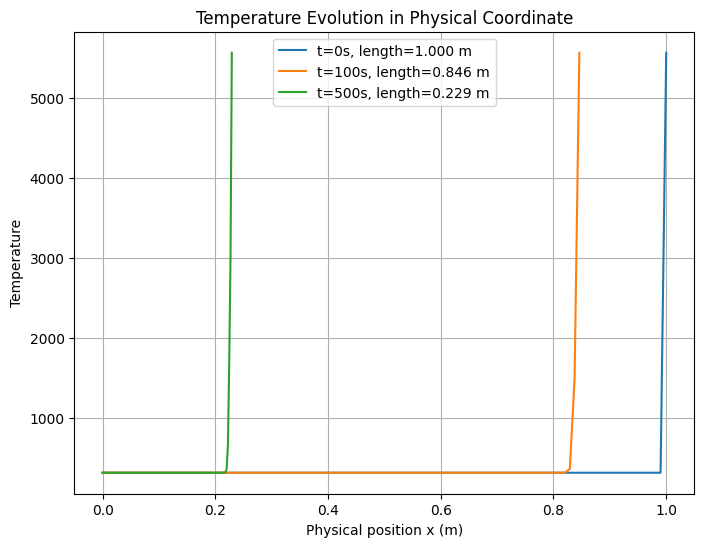

In [ ]:
import numpy as np
import matplotlib.pyplot as pl

# --------------------------------------------------
# Grid
# --------------------------------------------------

xi_0 = 0
xi_1 = 1
dxi = 0.01
xi = np.arange(xi_0, xi_1 + dxi, dxi)
Nxi = len(xi)

t_0 = 0
t_1 = 7200
dt = 1
t = np.arange(t_0, t_1 + dt, dt)
Nt = len(t)

# --------------------------------------------------
# Boundary and initial conditions
# --------------------------------------------------

Ta = 311
Tb = 5566
T0 = 311

# --------------------------------------------------
# Moving boundary parameters
# --------------------------------------------------

L = 1
Gamma = 1e-5

s_pos = np.zeros(Nt)

def sdot_from_T(Ts):

    # optional: no recession below ablation threshold
    if Ts < 1242:
        return 0.0

    val = (
        0.611282867808e-2
        + 0.787035208405e-4 * Ts
        - 0.148228353549e-6 * Ts**2
        + 0.767534556668e-10 * Ts**3
        - 0.103516560693e-13 * Ts**4
        + 0.447313136247e-18 * Ts**5
    )

    return max(val / 1000.0, 0.0)

# --------------------------------------------------
# Material conductivity
# --------------------------------------------------

def k_char(T):
    T_clip = np.clip(T, 922, 1922)
    k = (
        -1.537335668
        + 0.002896892266*T_clip
        - 0.1419927561e-5*T_clip**2
        + 0.461498664e-9*T_clip**3
    )
    return np.maximum(k, 1e-8)

# Convert conductivity to diffusivity
rho_ref = 320.37
cp_ref = 1725.0

def alpha_char(T):
    return k_char(T) / (rho_ref * cp_ref)

# --------------------------------------------------
# Density / Arrhenius parameters
# --------------------------------------------------

rho_v = 512.59
rho_c = 320.37

A_arr = 422709.5
n_order = 1.0
Ea_over_R = 12944.44

C_rho = 1.0

# --------------------------------------------------
# Initial arrays
# --------------------------------------------------

T = np.zeros((Nt, Nxi))
T[0, :] = T0
T[0, 0] = Ta
T[0, -1] = Tb

rho = np.zeros((Nt, Nxi))
rho[0, :] = rho_v

tol = 1e-6
max_iter = 50

# --------------------------------------------------
# Time stepping
# --------------------------------------------------

for p in range(1, Nt):

    Tn = T[p-1, :].copy()
    rhon = rho[p-1, :].copy()

    # --------------------------------------------------
    # 1. Update recession rate from surface temperature
    # --------------------------------------------------

    Ts = Tn[-1]
    sdot = sdot_from_T(Ts)

    s_pos[p] = s_pos[p-1] + dt * sdot

    delta = L - s_pos[p]

    if delta <= 1e-6:
        print("Material fully recessed at t =", t[p])
        T = T[:p, :]
        rho = rho[:p, :]
        t = t[:p]
        Nt = p
        break

    # --------------------------------------------------
    # 2. Update rho using Arrhenius law
    # --------------------------------------------------

    fraction = (rhon - rho_c) / (rho_v - rho_c)
    fraction = np.clip(fraction, 0.0, 1.0)

    rho_t = -A_arr * fraction**n_order * np.exp(
        -Ea_over_R / np.maximum(Tn, 1e-12)
    )

    rho_new = rhon + dt * rho_t
    rho_new = np.maximum(rho_new, rho_c)

    rho[p, :] = rho_new

    # --------------------------------------------------
    # 3. Picard iteration for implicit temperature solve
    # --------------------------------------------------

    T_guess = Tn.copy()

    for m in range(max_iter):

        A = np.zeros((Nxi, Nxi))

        b = Tn.copy()

        # If density loss is endothermic, use + C_rho*rho_t
        # If density loss releases heat, use - C_rho*rho_t
        b[1:-1] += dt * C_rho * rho_t[1:-1]

        # Dirichlet boundary conditions
        A[0, 0] = 1
        b[0] = Ta

        A[-1, -1] = 1
        b[-1] = Tb

        for i in range(1, Nxi-1):

            # lagged diffusivity from previous Picard guess
            Kp = alpha_char(0.5 * (T_guess[i] + T_guess[i+1]))
            Km = alpha_char(0.5 * (T_guess[i] + T_guess[i-1]))

            Cp = dt * Kp / (dxi**2 * delta**2)
            Cm = dt * Km / (dxi**2 * delta**2)

            # moving-boundary + Gamma advection velocity
            v = (xi[i] * sdot - Gamma) / delta

            A[i, i-1] = -Cm - dt * max(v, 0) / dxi
            A[i, i]   = 1 + Cp + Cm + dt * abs(v) / dxi
            A[i, i+1] = -Cp + dt * min(v, 0) / dxi

        T_new = np.linalg.solve(A, b)

        if np.linalg.norm(T_new - T_guess, ord=np.inf) < tol:
            break

        T_guess = T_new

    T[p, :] = T_new

# --------------------------------------------------
# Plot
# --------------------------------------------------
times = [0, 100, 500, 1000, 1500, 1900]

pl.figure(figsize=(8,6))

for tt in times:
    if tt <= t[-1]:
        idx = int(tt / dt)

        delta_now = L - s_pos[idx]

        if delta_now > 0:
            x_phys = xi * delta_now

            pl.plot(
                x_phys,
                T[idx, :],
                label=f"t={tt}s, length={delta_now:.3f} m"
            )

pl.xlabel("Physical position x (m)")
pl.ylabel("Temperature")
pl.title("Temperature Evolution in Physical Coordinate")
pl.legend()
pl.grid(True)
pl.show()